In [ ]:
#install.packages("DoubletFinder")
#install.packages("presto")

#install.packages("hdf5r")

In [ ]:
#remotes::install_github('chris-mcginnis-ucsf/DoubletFinder', force = TRUE)

In [1]:
library(Seurat)
library(tidyverse)
library(hdf5r)
library(patchwork)
library(DoubletFinder)
library(presto) # for differential expression
library(glmGamPoi) # for sctransform

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“‘timedatectl’ indicates the non-existent timezone name ‘n/a’”
Warning message:
“Your system is mis-configured: ‘/etc/localtime’ is not a symlink”
Warning message:
“‘/etc/localtime’ is not identical to any known timezone file”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘hdf5r’


The following object 

#### The project GSE193462 is from Nanduri et.al. "Epigenetic regulation of white adipose tissue plasticity and energy metabolism by nucleosome binding HMGN proteins"
#### They have done bulk, sc rna and atac se and chipseq.

#### In this project there 9 samples for which they have done scrna seq at day 0 and day 6 from WT wildtype and DK gene knockout mouse samples

#untar the raw file
untar("GSE193462_RAW.tar")

In [6]:
list.files()

[1] "environments"              "GSE193462_RAW.tar"        
 [3] "GSM5808067_W10_raw.tar.gz" "GSM5808068_W20_raw.tar.gz"
 [5] "GSM5808069_D10_raw.tar.gz" "GSM5808070_D20_raw.tar.gz"
 [7] "GSM5808071_W16_raw.tar.gz" "GSM5808072_W26_raw.tar.gz"
 [9] "GSM5808073_D16_raw.tar.gz" "GSM5808074_D26_raw.tar.gz"
[11] "lost+found"                "qc_tut.ipynb"

In [7]:
#untar each sample
files <- list.files(pattern = "GSM.*tar.gz")

for (f in files) {
  untar(f)
}

In [8]:
list.dirs(recursive = FALSE)

[1] "./.environments"           "./.ipynb_checkpoints"     
 [3] "./.scripts"                "./.Singlecell"            
 [5] "./.sparkmagic"             "./.spatialtranscriptomics"
 [7] "./D10_raw"                 "./D16_raw"                
 [9] "./D20_raw"                 "./D26_raw"                
[11] "./environments"            "./lost+found"             
[13] "./W10_raw"                 "./W16_raw"                
[15] "./W20_raw"                 "./W26_raw"

## 📌 Why use `min.cells = 3` and `min.features = 200` in Seurat

These parameters perform **initial quality filtering** in single-cell RNA-seq analysis. They are heuristic starting points to remove noise before detailed QC.

---

### 🔹 `min.cells = 3` (gene-level filter)

**Definition:**  
Keep genes that are detected in **at least 3 cells**.

**Why it is used:**

- Many genes appear in only 1–2 cells due to:
  - ambient RNA  
  - sequencing noise  
  - mapping artefacts  
- Such rare genes:
  - increase sparsity  
  - add statistical noise  
  - do not help clustering

**Effect:**  
Removes extremely low-information genes while retaining biologically relevant ones.

**Key point:**  
This filter acts on **genes**, not cells.

---

### 🔹 `min.features = 200` (cell-level filter)

**Definition:**  
Keep cells that have **at least 200 detected genes**.

**Biological reasoning:**

Droplet-based scRNA data contains many barcodes representing:

- empty droplets  
- dead cells  
- broken cells  
- ambient RNA background  

These typically show very few detected genes.

**Typical pattern:**

- Good cells: ~1000–5000 genes  
- Poor-quality droplets: <200 genes  

**Effect:**  
Removes obvious low-quality or empty droplets.

---

### ⚠️ Important note

These are **initial loose filters**, not final QC thresholds.

**Recommended workflow:**

1. Create Seurat object with basic filters  
2. Examine QC metrics (`nFeature_RNA`, `nCount_RNA`, `% mitochondrial`)  
3. Apply dataset-specific cutoffs based on distributions  

---

### ✅ Summary table

| Parameter | Filters | Purpose |
|----------|--------|--------|
| `min.cells = 3` | Rare genes | Reduce noise and sparsity |
| `min.features = 200` | Low-quality cells | Remove empty droplets |

---

**Take-home:** These settings provide a clean starting dataset, but proper QC should always be data-driven.

In [10]:
library(Seurat)

#recursively read all the .h5 files from the list of folders provided as sample_dirs
sample_dirs <- c(
  "W10_raw","W20_raw","D10_raw","D20_raw",
  "W16_raw","W26_raw","D16_raw","D26_raw"
)

##function to read all the samples as surat object
seurat_list <- lapply(sample_dirs, function(x) {
  
  h5_file <- list.files(x, pattern = "\\.h5$", full.names = TRUE)
  
  data <- Read10X_h5(h5_file)
  
  CreateSeuratObject(
    counts = data, #data is h5 file
    project = gsub("_raw$", "", x),  # clean project name to remove _raw from each folder name
    min.cells = 3, #the gene should be present in atleast 3 cells
    min.features = 200 #there should be minmum 200 genes per cell ##in the paper they have used 500
  )
})

## ✅ Clean list names
clean_names <- gsub("_raw$", "", sample_dirs)
names(seurat_list) <- clean_names

In [25]:
data_d10_wf <- Read10X_h5("./D10_raw/raw_feature_bc_matrix.h5")
  
D10= CreateSeuratObject(
    counts = data_d10_wf, #data is h5 file
    project = "D10"  # clean project name to remove _raw from each folder name
    #min.cells = 3, #the gene should be present in atleast 3 cells
    #min.features = 200 #there should be minmum 200 genes per cell
)

In [26]:
D10

An object of class Seurat 
32285 features across 2113498 samples within 1 assay 
Active assay: RNA (32285 features, 0 variable features)
 1 layer present: counts

In [28]:
data_d10_fl <- Read10X_h5("./D10_raw/raw_feature_bc_matrix.h5")
  
D10_f= CreateSeuratObject(
    counts = data_d10_fl, #data is h5 file
    project = "D10",  # clean project name to remove _raw from each folder name
    min.cells = 3, #the gene should be present in atleast 3 cells
    min.features = 200 #there should be minmum 200 genes per cell
)
D10_f

An object of class Seurat 
19176 features across 44540 samples within 1 assay 
Active assay: RNA (19176 features, 0 variable features)
 1 layer present: counts

##### In this example witout filtering the sample **D10** had **32285** features in **2113498** cells
##### But after filtering it got reduced to **19176** features in **44540** cells 

In [ ]:
###merging

#### Merge the Seurat objects into one combined object and assign a project name

- Seurat `merge()` requires a first object to start with, so `[1]` represents the first sample used as the base.
- `[-1]` in `y` means all remaining samples except the first one will be merged into the base object.
- `add.cell.ids` adds the sample name as a prefix to each cell barcode (e.g., `W10_AAAC...`) to keep cell IDs unique across samples.
- `project` assigns a project identifier to the merged Seurat object.

In [50]:
adp <- merge(
  seurat_list[[1]],
  y = seurat_list[-1],
  add.cell.ids = names(seurat_list),
  project = "Adipose_scRNA"
)

In [51]:
adp
dim(adp)

An object of class Seurat 
21031 features across 438515 samples within 1 assay 
Active assay: RNA (21031 features, 0 variable features)
 8 layers present: counts.W10, counts.W20, counts.D10, counts.D20, counts.W16, counts.W26, counts.D16, counts.D26

[1]  21031 438515

## 📌 Why the number of features does not increase much after merging

In Seurat, **features refer to genes**, not cells. When multiple samples are merged, the number of cells increases substantially, but the number of genes usually changes only slightly.

---

### 🔹 Same reference genome

All samples in this study are:

- from the same species (*Mus musculus*)
- aligned to the same genome build (mm10)
- quantified using the same gene annotation

Because of this, most genes detected in one sample are also present in other samples.

---

### 🔹 Merge uses the union of genes

During `merge()`:

- Seurat takes the **union of all genes** across samples  
- missing genes in any sample are filled with zeros  

Therefore, only genes that were uniquely detected in some samples add to the total feature count.

**In this case:**
#### genes
- Single sample (D10): ~19k genes  
- Combined object: ~21k genes  
- Increase: small (~2k) → **expected**

#### cells
- Single sample (D10): ~44k cells  
- Combined object: ~438k cells  
- Increase: large cells (~400k) → **expected**
---

### 🔹 Cells behave differently

Cells are unique to each sample, so they are **additive** during merging.

| Quantity | Behavior after merge |
|----------|---------------------|
| Genes (features) | Small increase |
| Cells | Large increase |

This is why the merged object shows many more cells but only slightly more genes.

---

### ⚠️ Practical takeaway

A small increase in features after merging is **normal and expected** when:

- all samples use the same reference  
- the same gene annotation is used  
- and the biology is similar  

Always focus more on cell counts and QC metrics rather than expecting large changes in feature numbers.

In [15]:
head(adp@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA
,<chr>,<dbl>,<int>
W10_AAACCCACAATCCTTT-1,W10,326,255
W10_AAACCCACAATTGCAC-1,W10,576,396
W10_AAACCCACACATGAAA-1,W10,287,224
W10_AAACCCACACGTCATA-1,W10,308,229
W10_AAACCCACAGACGCTC-1,W10,262,214
W10_AAACCCACAGCCTACG-1,W10,802,527


In [52]:
#save merged adp
saveRDS(adp, file = "adp_merged.rds")

## 📌 Understanding `nFeature_RNA` and `nCount_RNA` in scRNA-seq

These two metrics are core quality control (QC) measures in single-cell RNA-seq and help assess cell quality and detect potential artefacts.

---

### 🔹 `nFeature_RNA`

**Definition:**  
Number of genes detected (non-zero counts) in each cell.

**Interpretation:**

- Low values → empty droplets, dead or poor-quality cells  
- Very high values → possible doublets or multiplets  
- Typical good cells (10x mammalian): ~1,000–5,000 genes  

**Intuition:**  
Represents the **gene diversity** captured in a cell.

---

### 🔹 `nCount_RNA`

**Definition:**  
Total number of RNA molecules (UMIs) detected in each cell.

**Interpretation:**

- Low values → low capture efficiency or empty droplets  
- Very high values → possible doublets or highly active cells  
- Typical good cells (10x mammalian): ~2,000–20,000 UMIs  

**Intuition:**  
Represents the **total RNA abundance** in a cell.

---

### 🔹 Relationship between the two

In good-quality data:

- `nCount_RNA` and `nFeature_RNA` are strongly positively correlated  
- Higher RNA counts usually lead to more detected genes  

Outliers to watch for:

- Very low values → likely poor-quality cells  
- Extremely high values → potential doublets  
- High counts but low features → possible ambient RNA contamination  

---

### ✅ Practical takeaway

| Metric | Indicates | Main QC role |
|--------|----------|-------------|
| `nFeature_RNA` | Gene diversity | Detect low-quality cells and doublets |
| `nCount_RNA` | Total RNA content | Detect empty droplets and multiplets |

**Best practice:** Always evaluate these two metrics together using violin and scatter plots before filtering.

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


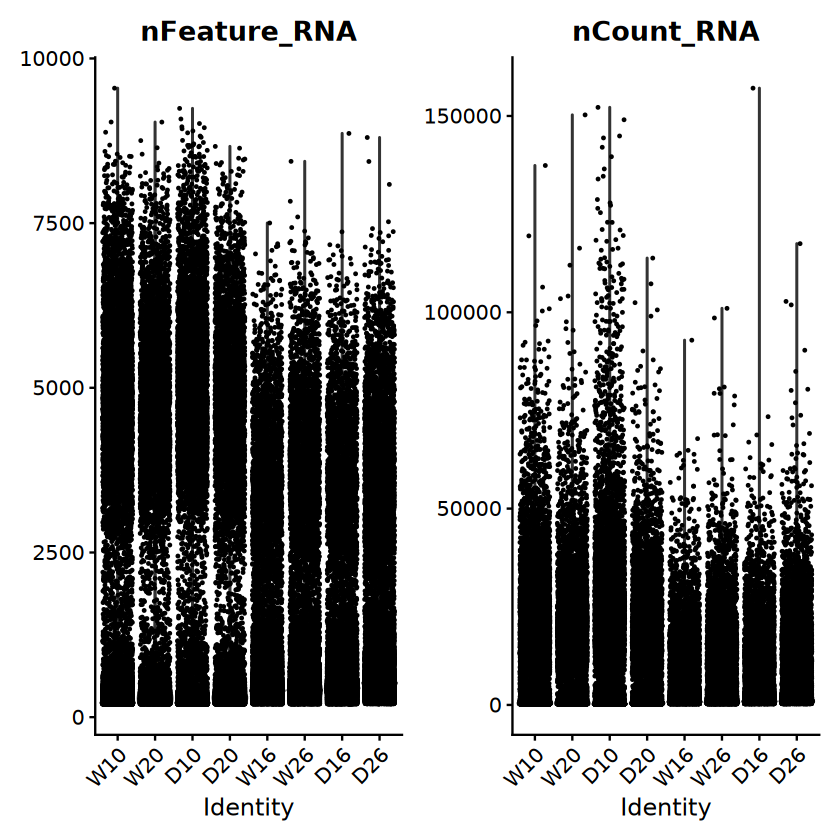

In [54]:
## plot the unique number of gene count per cell with > 1 count n_Feature_RNA and 
## UMI total genes (sum of count  of each genes) n_Count_RNA

## Violin plots
VlnPlot(
  adp,
  features = c("nFeature_RNA", "nCount_RNA"),
  ncol = 2,
  pt.size = 0.1,
  raster = FALSE
)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



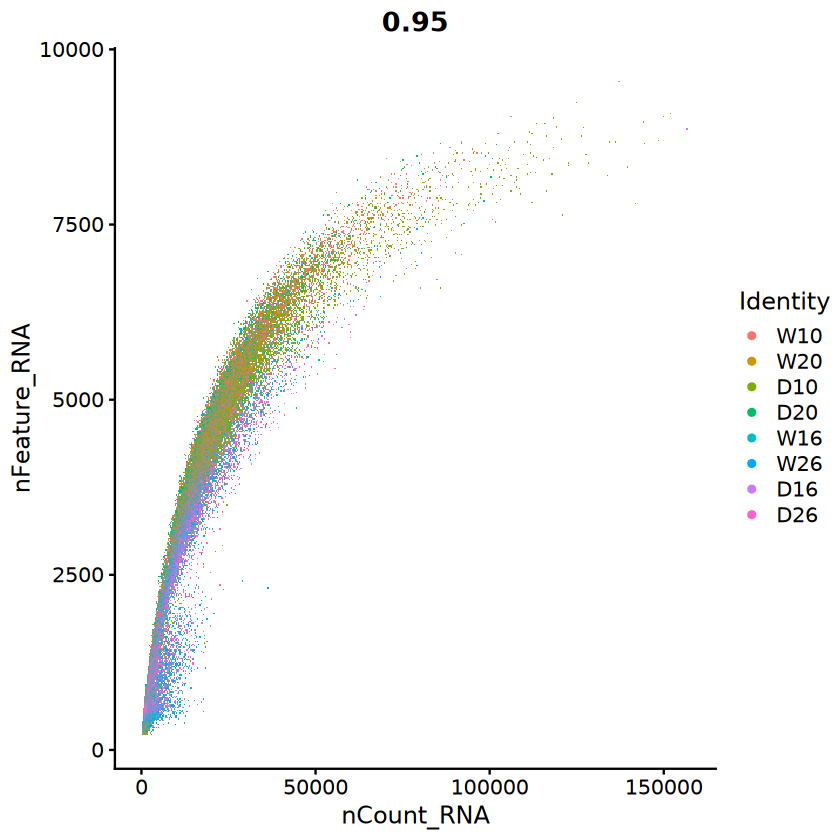

In [55]:
## Scatter plots
FeatureScatter(adp, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")

In [56]:
## (mouse genes start with "mt-")
## to recognise mitochondrial dna
adp[["percent.mt"]] <- PercentageFeatureSet(adp, pattern = "^mt-")

In [57]:
## (optional) ribosomal percentage
## to recognise ribosomal dna
adp[["percent.ribo"]] <- PercentageFeatureSet(adp, pattern = "^Rpl|^Rps")

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


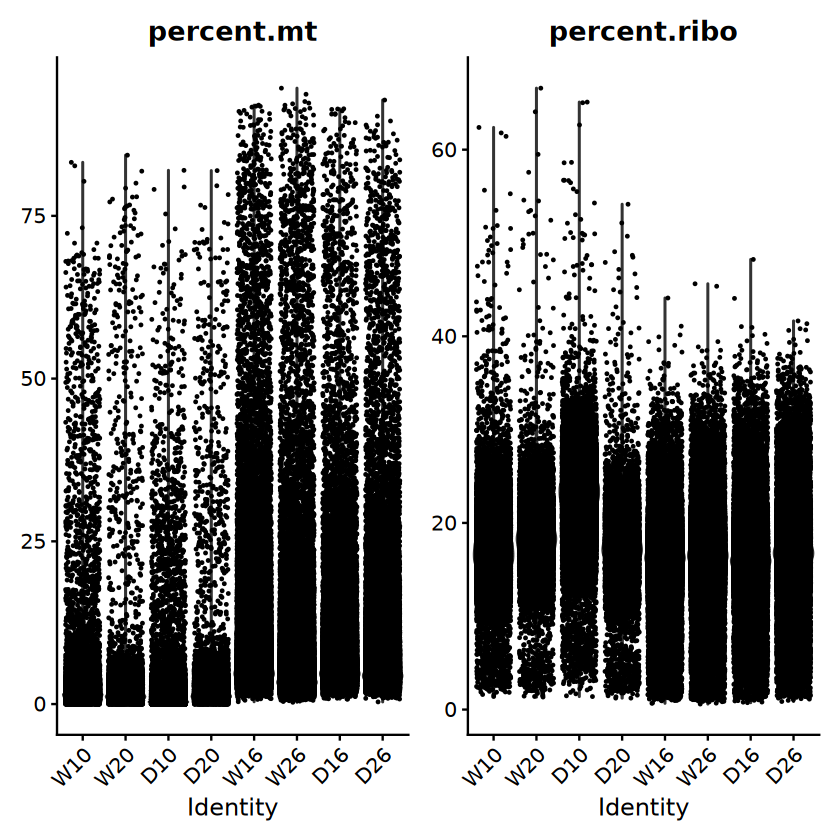

In [58]:
## Violin plots
VlnPlot(
  adp,
  features = c("percent.mt", "percent.ribo"),
  ncol = 2,
  pt.size = 0.1,
  raster = FALSE
)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



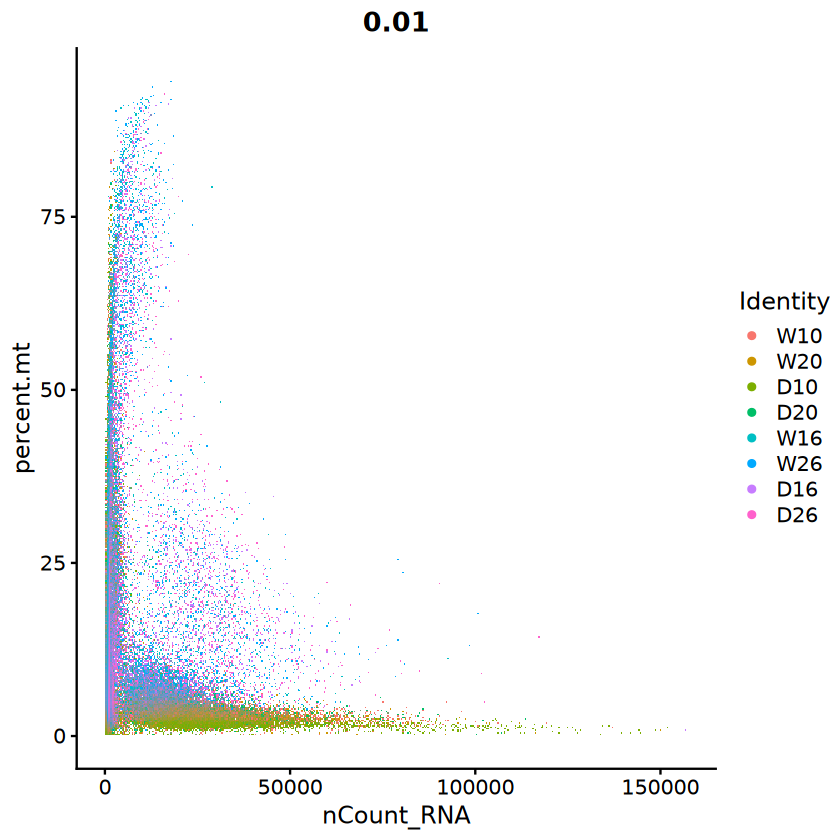

In [59]:
## Scatter plots
FeatureScatter(adp, feature1 = "nCount_RNA", feature2 = "percent.mt")

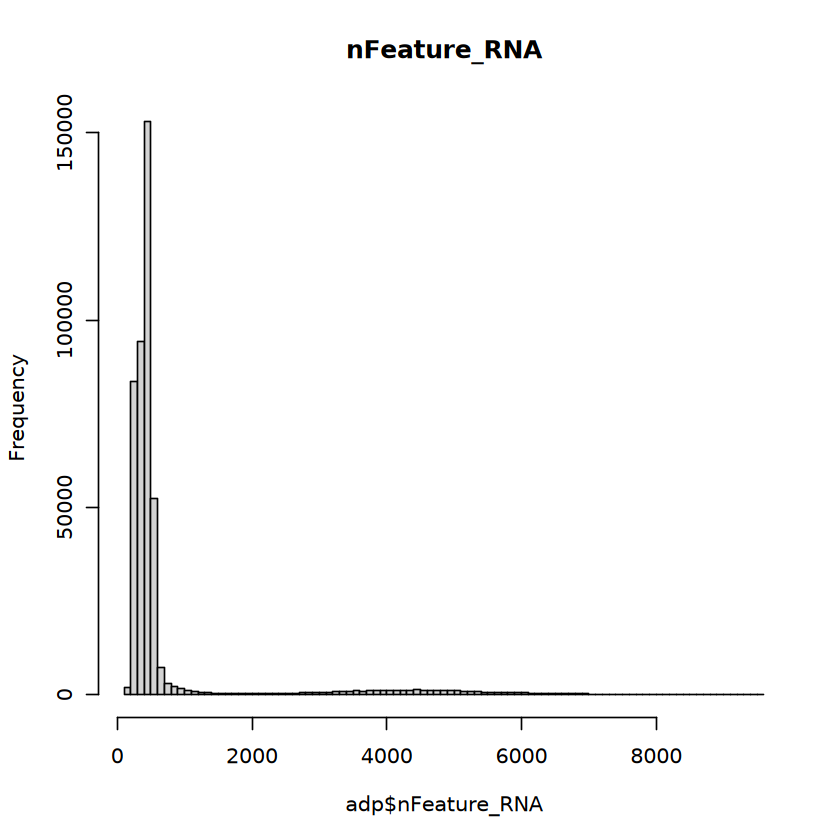

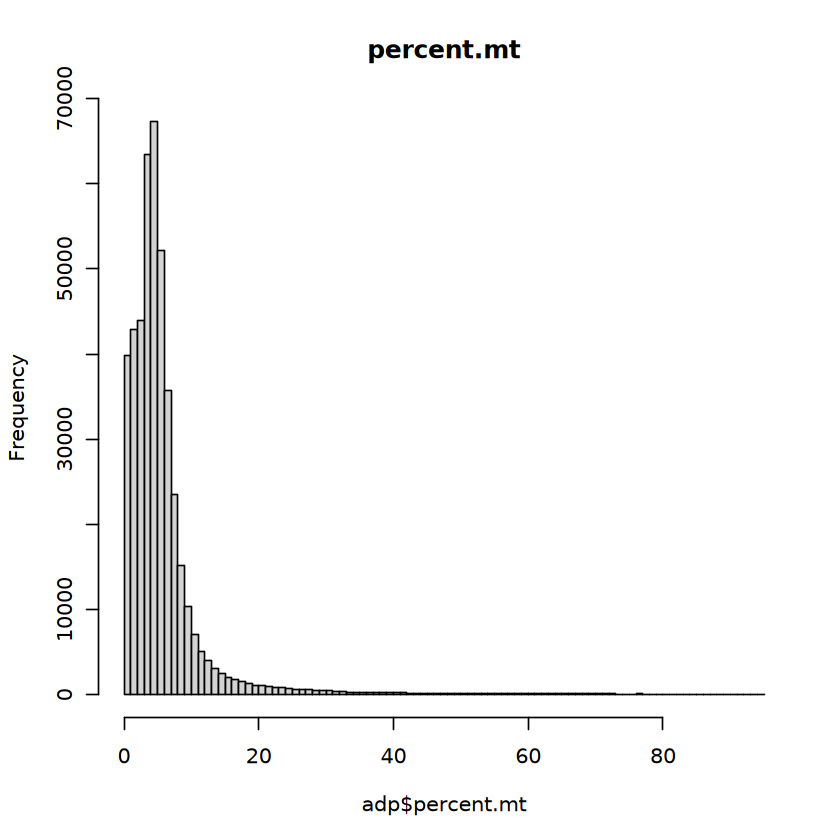

In [60]:
## --------------------------------

## Histogram of genes per cell
hist(adp$nFeature_RNA, breaks = 100, main = "nFeature_RNA")

## Histogram of mitochondrial %
hist(adp$percent.mt, breaks = 100, main = "percent.mt")

In [61]:
## --------------------------------
## Apply filtering (INITIAL — adjust after inspection)
## ⚠️ Tune thresholds based on plots
## --------------------------------

adp_sub <- subset(
  adp,
  subset =
    nFeature_RNA > 300 &
    nFeature_RNA < 6000 &
    percent.mt < 20
)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


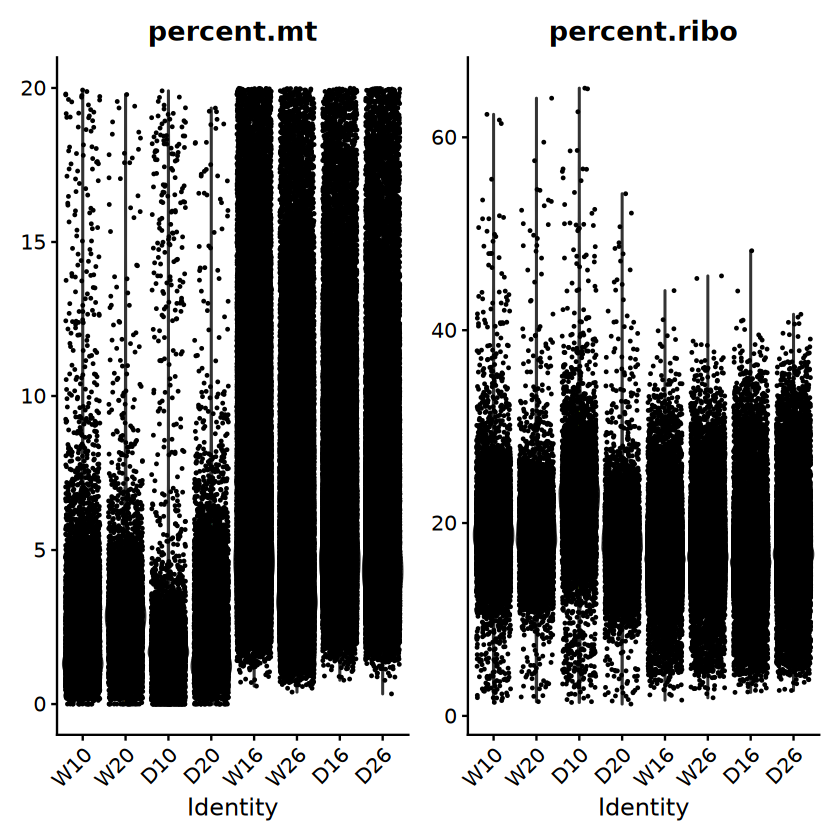

In [62]:
## Do violin plot again to see the percentages after removal
VlnPlot(
  adp_sub,
  features = c("percent.mt", "percent.ribo"),
  ncol = 2,
  pt.size = 0.1,
  raster = FALSE
)

In [63]:
#cells before filtering
table(adp$orig.ident)


  D10   D16   D20   D26   W10   W16   W20   W26 
44540 79235 17599 82272 37888 81452 14498 81031 

In [64]:
#cells after filtering
table(adp_sub$orig.ident)


  D10   D16   D20   D26   W10   W16   W20   W26 
 7204 72687  9075 77768 15509 71878  7108 73905 

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



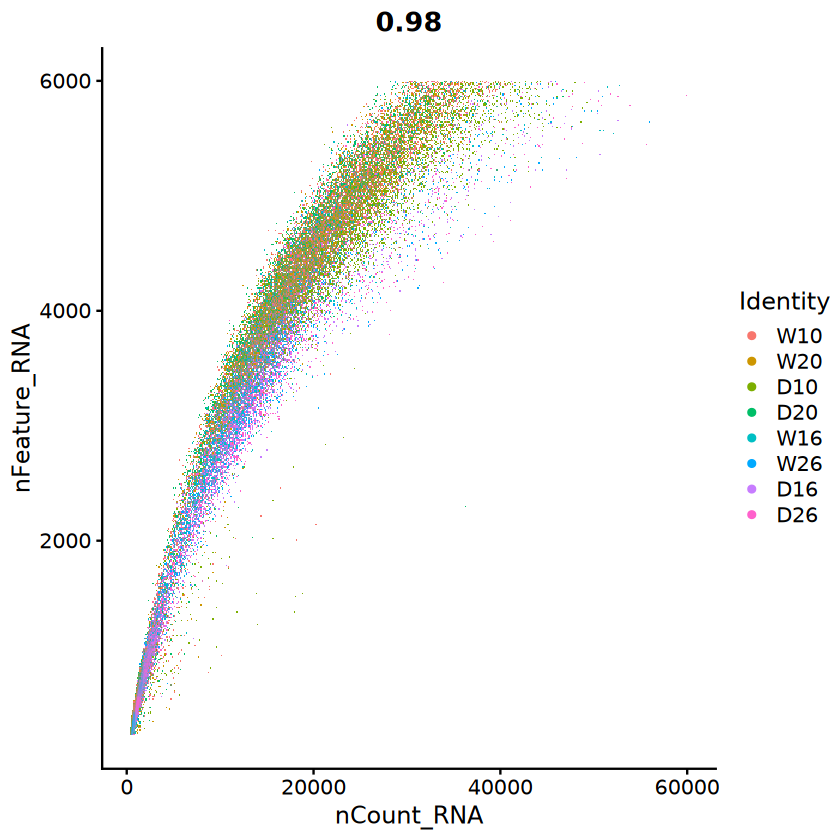

In [65]:
## Scatter plots for subset to see the feature distribution
FeatureScatter(adp_sub, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")

In [66]:
saveRDS(adp_sub, file = "adp_merged_sub.rds")

In [2]:
adp <- readRDS("adp_merged_sub.rds")

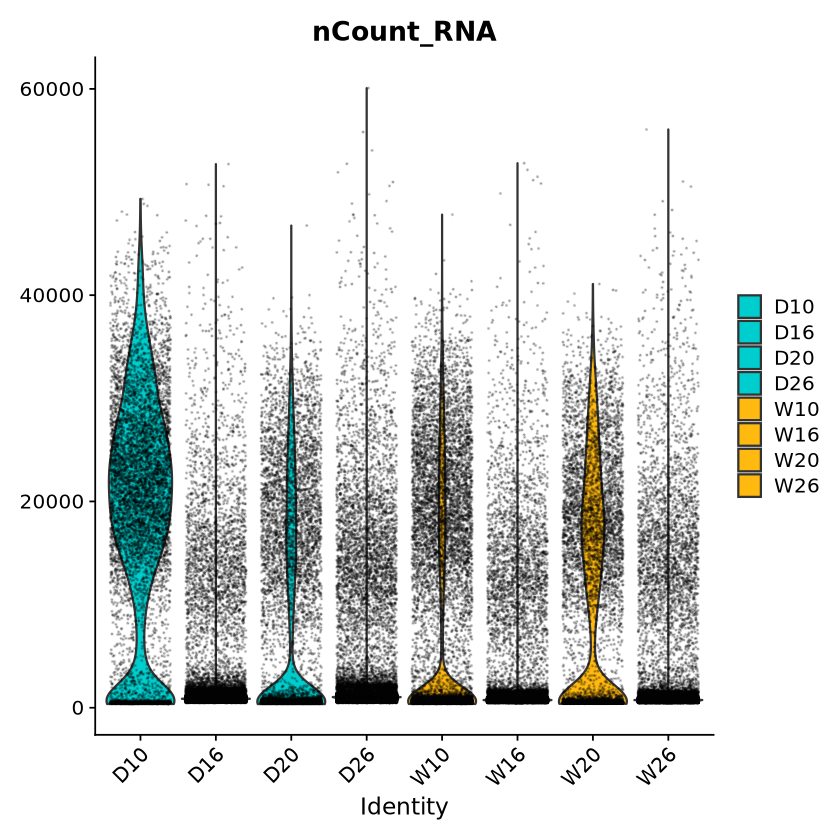

In [4]:
#plot the count of features and UMI before normalising
metadata <- adp@meta.data

cnames<-setNames(rep(c("cyan3","darkgoldenrod1"),each=4),levels(factor(metadata$orig.ident))) 

# plot
VlnPlot(adp, features = "nCount_RNA", layer="counts", group.by="orig.ident",raster=FALSE,alpha=0.2) +
  scale_fill_manual(values=cnames) 

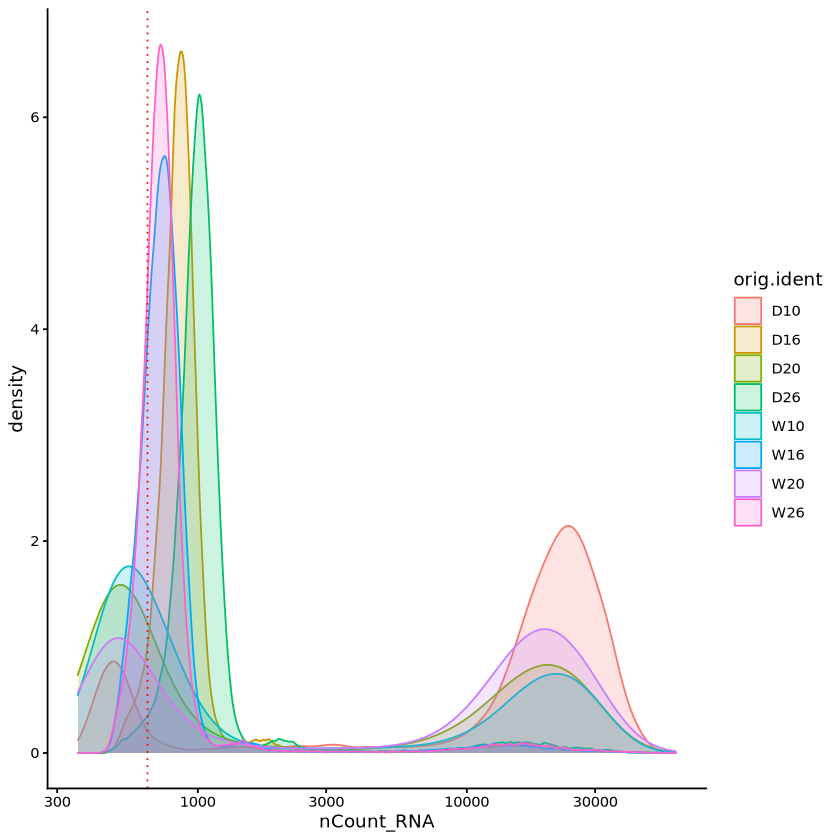

In [5]:
metadata %>% 
    ggplot(aes(color=orig.ident, x=nCount_RNA, fill= orig.ident)) + 
    geom_density(alpha = 0.2) + 
    theme_classic() +
    scale_x_log10() + 
    geom_vline(xintercept = 650,color="red",linetype="dotted")

In [3]:
##add a column called condition and add the rows based in the sample name
#if there W in the sample name its wild type
#else its DK knock out sample
adp$condition <- ifelse(str_detect(adp@meta.data$orig.ident, "^W"),
                        "WT","DKO")

In [4]:
#add a column called 
adp$time_point <- ifelse(str_detect(adp@meta.data$orig.ident, "0"),
                         "Day 0","Day 6")

In [5]:
adp$cond_tp <- paste(adp$condition, adp$time_point)

In [ ]:
adp@meta.data

In [10]:
head(Cells(adp,layer="counts.W10"))

[1] "W10_AAACCCACAATTGCAC-1" "W10_AAACCCACAGCCTACG-1" "W10_AAACCCACAGTGACCC-1"
[4] "W10_AAACCCACATAGATGA-1" "W10_AAACCCACATTAAGCC-1" "W10_AAACCCAGTCCAGGTC-1"

In [8]:
# use multicore parallelism (Linux/SageMaker)
plan("multicore", workers = 28)

# increase memory limit for futures
options(future.globals.maxSize = 200 * 1024^3)  # 200 GB

#adp_filt <- SCTransform(adp, vars.to.regress = "percent.mt")

In [9]:
adp_filt <- SCTransform(
  adp,
  vars.to.regress = "percent.mt",
  method = "glmGamPoi",
  verbose = TRUE
)

Running SCTransform on assay: RNA

vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 17479 by 15509

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 5000 cells

Found 314 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 17479 genes

Computing corrected count matrix for 17479 genes

Calculating gene attributes

Wall clock passed: Time difference of 1.504224 mins

Determine variable features

Regressing out percent.mt

Centering data matrix

Place corrected count matrix in counts slot

vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 16780 by 7108

Model formula is y ~

## ============================================
## 🔬 DoubletFinder pipeline for your Seurat object
## (run AFTER normalization + PCA)
## ============================================

library(Seurat)
library(DoubletFinder)

## --------------------------------------------
## 1️⃣ Standard preprocessing (if not already done)
## --------------------------------------------

# Normalize
adp <- NormalizeData(adp, normalization.method = "LogNormalize", scale.factor = 10000)

# Variable features
adp <- FindVariableFeatures(adp, selection.method = "vst", nfeatures = 2000)

# Scale (regress mitochondrial if following paper)
adp <- ScaleData(adp, vars.to.regress = "percent.mt")

# PCA
adp <- RunPCA(adp, npcs = 30, verbose = FALSE)

## --------------------------------------------
## 2️⃣ Parameter sweep to find optimal pK
## --------------------------------------------

sweep.res <- paramSweep_v3(adp, PCs = 1:10, sct = FALSE)
sweep.stats <- summarizeSweep(sweep.res, GT = FALSE)
bcmvn <- find.pK(sweep.stats)

## 📊 Visualize pK optimization
plot(bcmvn$pK, bcmvn$BCmetric, type = "b", xlab = "pK", ylab = "BCmetric")

## 👉 Choose the pK corresponding to the peak BCmetric
## Example (replace with your chosen value):
best_pK <- bcmvn$pK[which.max(bcmvn$BCmetric)]
best_pK <- as.numeric(as.character(best_pK))

## --------------------------------------------
## 3️⃣ Estimate expected doublets
## --------------------------------------------

n_cells <- ncol(adp)

# Typical 10x doublet rate ~7.5%
doublet_rate <- 0.075
nExp <- round(n_cells * doublet_rate)

nExp

## --------------------------------------------
## 4️⃣ Run DoubletFinder
## --------------------------------------------

adp <- doubletFinder_v3(
  adp,
  PCs = 1:10,
  pN = 0.25,
  pK = best_pK,
  nExp = nExp,
  reuse.pANN = FALSE,
  sct = FALSE
)

## --------------------------------------------
## 5️⃣ Inspect results
## --------------------------------------------

# Find the classification column automatically
colnames(adp@meta.data)[grep("DF.classifications", colnames(adp@meta.data))]

# View counts
table(adp@meta.data[, grep("DF.classifications", colnames(adp@meta.data))])

## --------------------------------------------
## 6️⃣ Subset singlets
## --------------------------------------------

df_col <- grep("DF.classifications", colnames(adp@meta.data), value = TRUE)

adp <- subset(adp, subset = get(df_col) == "Singlet")

## --------------------------------------------
## 7️⃣ Save checkpoint
## --------------------------------------------

saveRDS(adp, "adp_after_doublet_removal.rds")

In [10]:
adp_filt <- RunPCA(adp_filt, verbose = FALSE, assay="SCT")

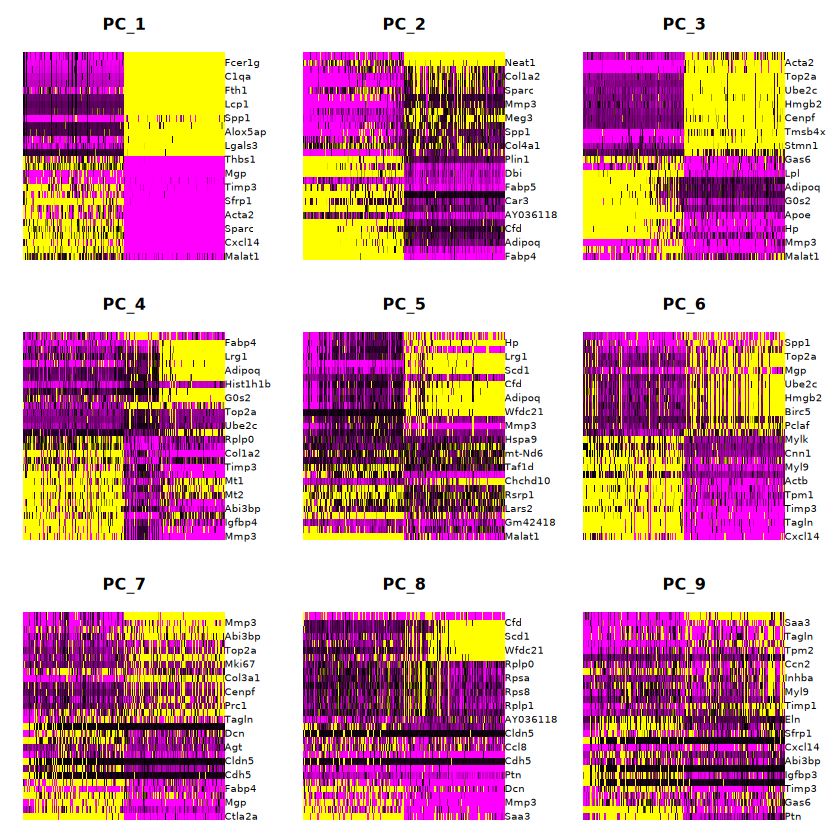

In [11]:
# dimensions 1 to 9
DimHeatmap(adp_filt, dims = 1:9, cells = 500, balanced = TRUE,ncol=3)

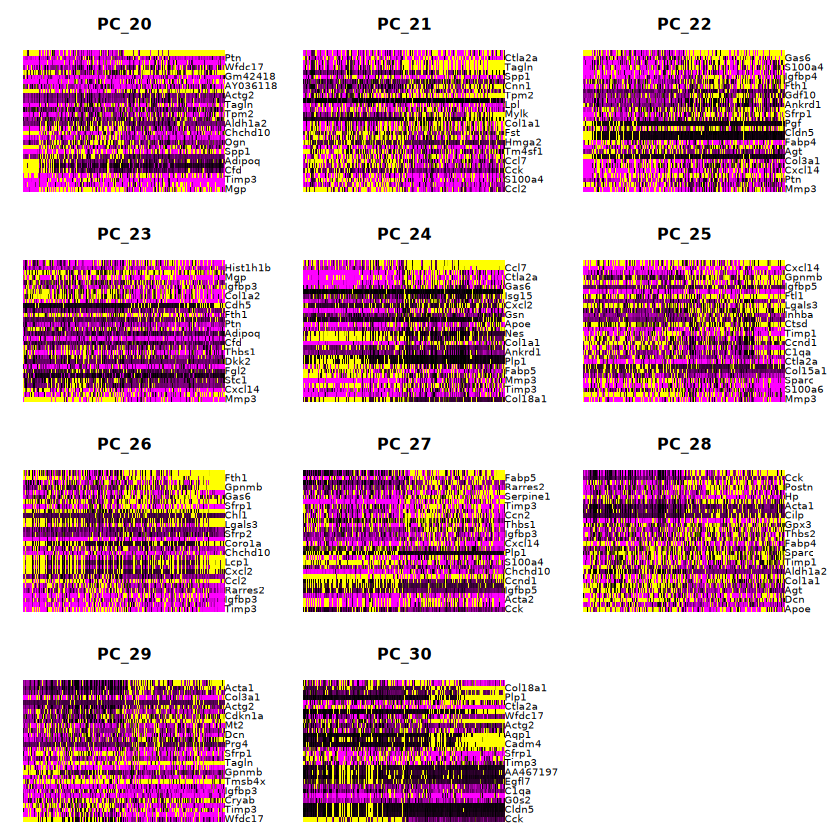

In [12]:
#dimensions 20 to 30
DimHeatmap(adp_filt, dims = 20:30, cells = 500, balanced = TRUE,ncol=3)

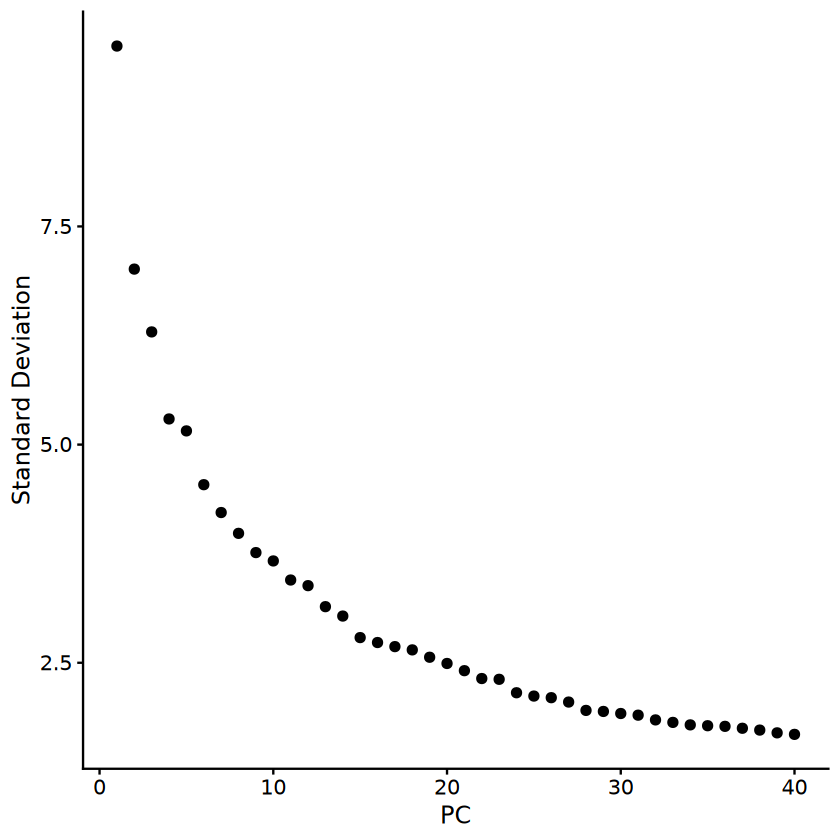

In [13]:
ElbowPlot(adp_filt, ndims = 40)

In [26]:
adp_filt <- FindNeighbors(adp_filt, dims = 1:10)

Computing nearest neighbor graph

Computing SNN



In [27]:
adp_filt <- FindClusters(adp_filt, resolution = 0.1)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 335134
Number of edges: 6903173

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9455
Number of communities: 9
Elapsed time: 182 seconds


2 singletons identified. 7 final clusters.

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore". [future ‘future_lapply-1’ (432858c6b2d4483a350804577936b6ae-1026); on 432858c6b2d4483a350804577936b6ae@ip-172-16-21-73.us-west-2.compute.internal<27852>]”


In [32]:
#adp_filt <- RunUMAP(adp_filt,dims = 1:10)

adp_filt <- RunUMAP(
  adp_filt,
  dims = 1:10,
  min.dist = 0.2,
  n.neighbors = 30
)

10:46:31 UMAP embedding parameters a = 1.262 b = 1.003

10:46:31 Read 335134 rows and found 10 numeric columns

10:46:31 Using Annoy for neighbor search, n_neighbors = 30

10:46:31 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:47:12 Writing NN index file to temp file /tmp/RtmpjjjwEt/file6ccc638cf88f

10:47:12 Searching Annoy index using 28 threads, search_k = 3000

10:47:21 Annoy recall = 100%

10:47:22 Commencing smooth kNN distance calibration using 28 threads
 with target n_neighbors = 30

10:47:39 Initializing from normalized Laplacian + noise (using RSpectra)

10:47:57 Commencing optimization for 200 epochs, with 13113530 positive edges

10:47:57 Using rng type: pcg

10:54:29 Optimization finished



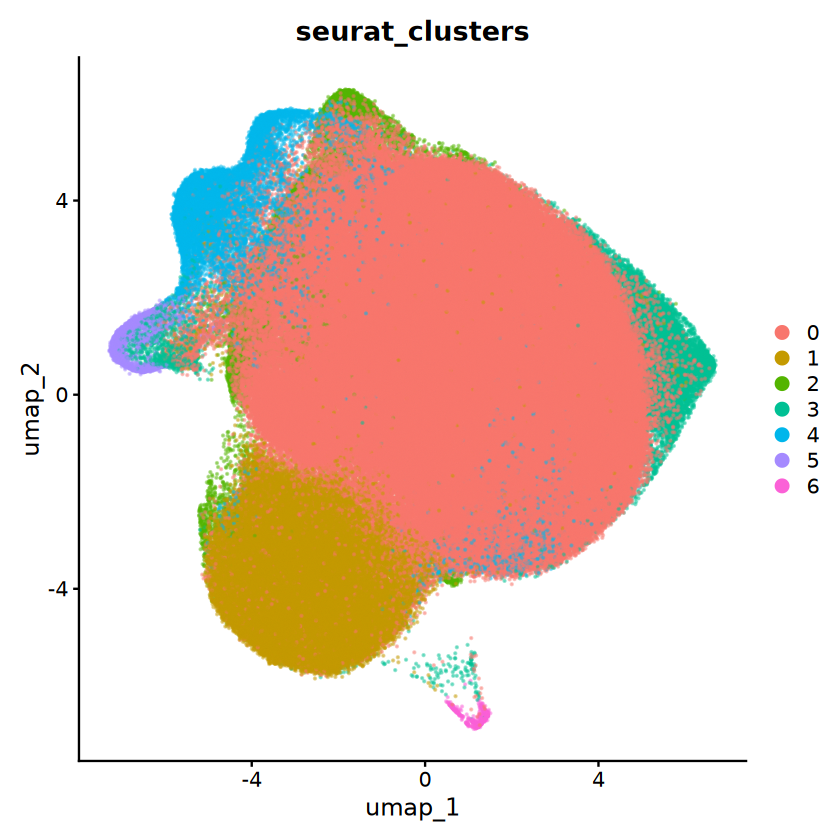

In [33]:
DimPlot(adp_filt, reduction = "umap", group.by = c(#"orig.ident", 
                                                   "seurat_clusters"),
                                                   #"time_point",
                                                   #"condition",
                                                   #"cond_tp"),
        alpha=0.4, ncol=1, raster=FALSE)

In [19]:
saveRDS(adp_filt, "adp_merge_filt_sctran_clust0.1.rds")

In [20]:
adp_filt<-PrepSCTFindMarkers(adp_filt,verbose=T)

Found 8 SCT models. Recorrecting SCT counts using minimum median counts: 728



In [34]:
#requires presto installation to speed up the next step
# devtools::install_github('immunogenomics/presto')
library(presto)
# find all markers
adp_filt_markers <- FindAllMarkers(adp_filt, only.pos = TRUE)


Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6



In [35]:
#ordering the results
adp_filt_markers <- adp_filt_markers %>% 
  arrange(cluster,desc(avg_log2FC), desc(p_val_adj))

#examine a small subset
adp_filt_markers %>%
    group_by(cluster) %>%
    slice_max(n = 5, order_by = avg_log2FC)


p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
2.267469e-59,0.8309895,0.016,0.009,4.314314e-55,0,Adhfe1
0.000000e+00,0.8206318,0.169,0.095,0.000000e+00,0,Cox7a1
1.457224e-46,0.8195967,0.013,0.007,2.772661e-42,0,Nat8l
0.000000e+00,0.8180832,0.534,0.296,0.000000e+00,0,Pnpla2
2.908361e-45,0.8176643,0.013,0.007,5.533739e-41,0,Mmaa
0.000000e+00,1.6829330,0.958,0.084,0.000000e+00,1,Spp1
1.096843e-10,0.4320021,0.011,0.008,2.086964e-06,1,Isoc2a
4.284787e-07,0.3684820,0.010,0.007,8.152665e-03,1,Tmem18
6.272798e-07,0.3486600,0.010,0.008,1.193525e-02,1,Zbtb33


Warning message in DoHeatmap(adp_filt, features = top20$gene):
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: Ptprc, Rac2, Lilr4b, Cd48, Cyth4, Fcgr3, Fcrls, Rgs1, Cd300c2, C1qc, Ctss, Spi1, Cd84, Clec4e, Ly86, Cd180, Cd200r4, Ccl12, Clec12a, Uchl4, Gm43150, Gm26724, Masp2, Col4a4, Gm43221, Gm26981, Gm26749, Gm50071, Gm17477, Gm29994, D830024N08Rik, Gm14764, Gm16982, Egfros, 4930565N06Rik, Gm26672, Gm45406, Gm16185, 4930562D21Rik, Gm12122, Gm12840, Agtr2, Lrrk1, Slc24a5, Map6, Hebp2, Sfxn3, Rarg, Ggta1, Pdgfd, Alkal1, Tnfsf8, Reg1, C1qtnf3, Mlana”


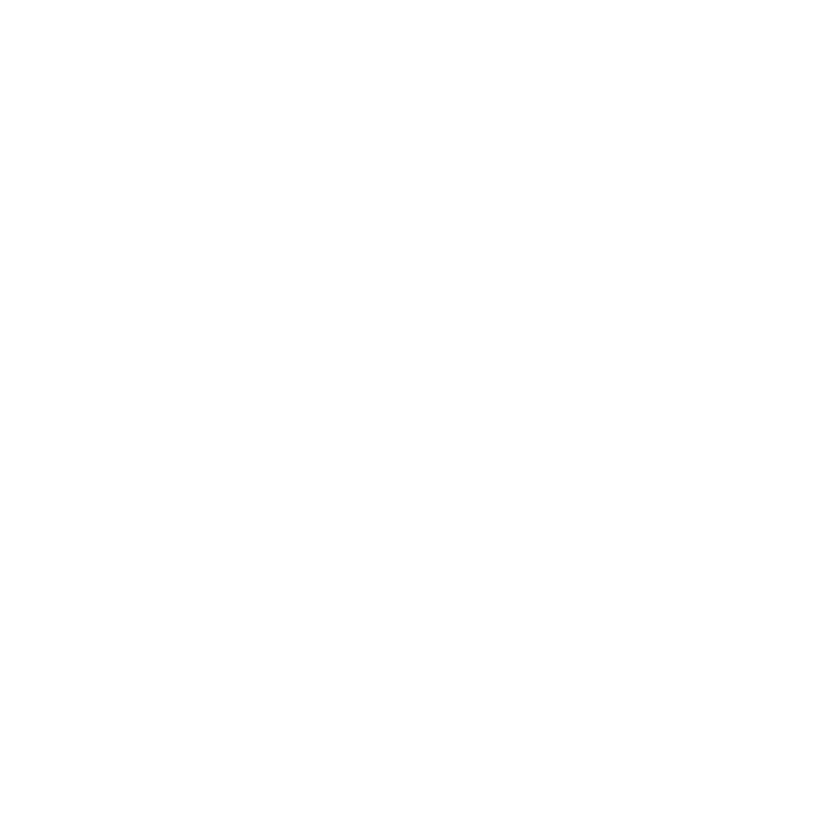

In [36]:
top20<-adp_filt_markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1) %>%
    slice_head(n = 20) %>%
    ungroup() 
DoHeatmap(adp_filt, features = top20$gene) + NoLegend()


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



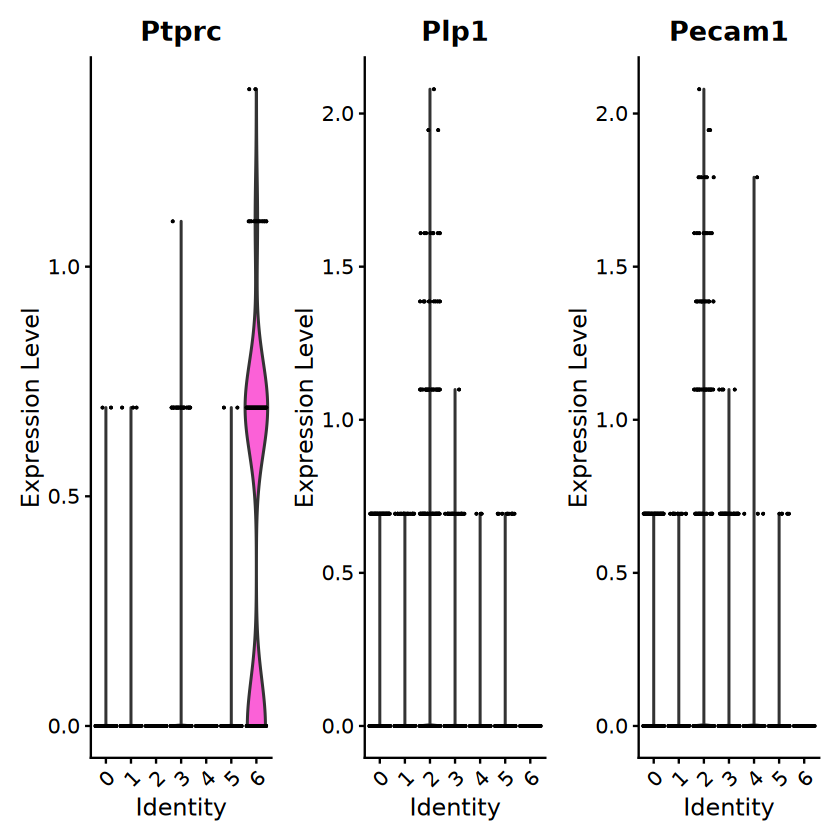

In [37]:
#contaminants
contam=c("Ptprc", "Plp1", "Pecam1")
#beige adipocytes
beige=c("Ucp1","Ppargc1a","Elovl3","Cidea")
#preadipocytes
preadip<-c('Mmp3', 'Cd142', 'Itgb1')
#proliferating
prolif<-'Mki67'
#differentiating adipocytes
diffadip<-c('Col5a3', 'Serpina3n')

VlnPlot(adp_filt, features=contam)
